In [1]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
nnfs.init()
class layer_dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights=0.01*np.random.randn(n_inputs, n_neurons)
        self.biases=np.zeros((1,n_neurons))
    def forward(self, inputs):
        self.output=np.dot(inputs,self.weights)+self.biases
class activation_relu:
    def forward(self, inputs):
        self.output=np.maximum(0,inputs)
class activation_softmax:
    def forward(self, inputs):
        exp_values=np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        probabilites=exp_values / np.sum(exp_values, axis=1, keepdims=True)
        self.output=probabilites
X,y=spiral_data(samples=100, classes=3)
dense1 = layer_dense(2,3)
activation1 = activation_relu()
dense2 = layer_dense(3,3)
activation2 = activation_softmax()
dense1.forward(X)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
activation2.forward(dense2.output)
print(activation2.output[:5])



[[0.33333334 0.33333334 0.33333334]
 [0.3333332  0.3333332  0.33333364]
 [0.3333329  0.33333293 0.3333342 ]
 [0.3333326  0.33333263 0.33333477]
 [0.33333233 0.3333324  0.33333528]]


In [ ]:
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

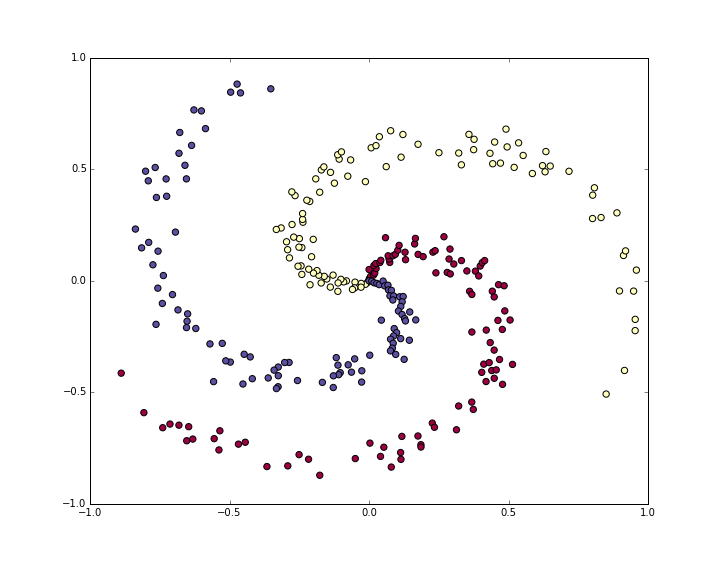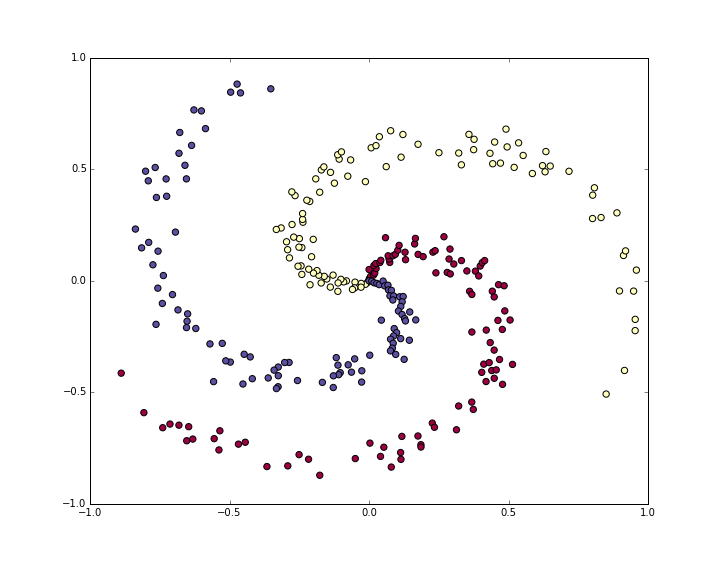